# JS04: Tugas Lab

Medical Cost Personal Datasets

## Deskripsi dataset

Dataset berisi usia, jenis kelamin, BMI, jumlah anak, status perokok, wilayah, dan biaya medis. Variabel charges digunakan sebagai target. Variabel lainnya digunakan sebagai fitur.

## Persiapan data

In [1]:
from pathlib import Path
from urllib.request import Request, urlopen

data_path = Path('insurance.csv')
data_path.parent.mkdir(parents=True, exist_ok=True)

if not data_path.exists():
    request = Request('https://1812311909-files.gitbook.io/~/files/v0/b/gitbook-x-prod.appspot.com/o/spaces%2FYHOv2XH8FJMJSMsnhwNa%2Fuploads%2FSDfCpCfaJNMqW4Lv0XPl%2Finsurance.csv?alt=media&token=4fca939a-da60-412e-92e2-fb4521118fba', headers={'User-Agent': 'Mozilla/5.0'})
    with urlopen(request) as response, data_path.open('wb') as file:
        file.write(response.read())

print(f'Dataset tersedia: {data_path}')

Dataset tersedia: insurance.csv


## Import library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR

## Pemahaman data

In [3]:
data = pd.read_csv('insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print('Ukuran data:', data.shape)
print('Jumlah missing value:', data.isna().sum().sum())
data.info()

Ukuran data: (1338, 7)
Jumlah missing value: 0
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


## Visualisasi data

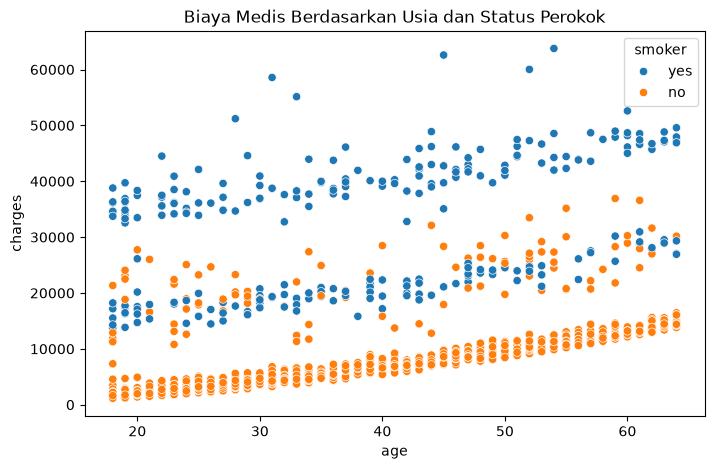

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x='age', y='charges', hue='smoker')
plt.title('Biaya Medis Berdasarkan Usia dan Status Perokok')
plt.show()

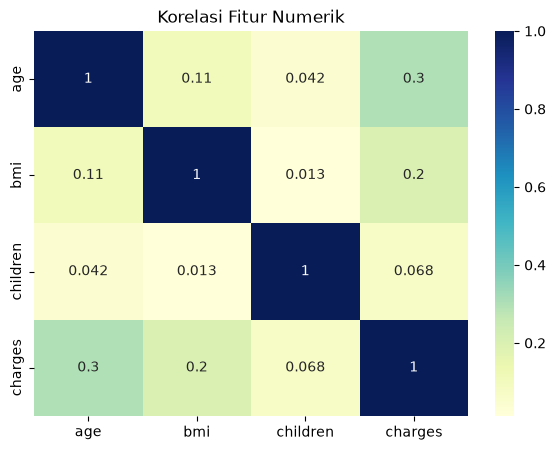

In [7]:
plt.figure(figsize=(7, 5))
sns.heatmap(data.select_dtypes(include=np.number).corr(), annot=True, cmap='YlGnBu')
plt.title('Korelasi Fitur Numerik')
plt.show()

## Menentukan fitur dan target

In [8]:
X = data.drop(columns='charges')
y = data['charges']

print('Fitur:', list(X.columns))
print('Target: charges')

Fitur: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
Target: charges


## Membagi data latih dan data uji

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Data latih:', X_train.shape)
print('Data uji:', X_test.shape)

Data latih: (1070, 6)
Data uji: (268, 6)


## Pra pengolahan data

In [10]:
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_transformer, numeric_features),
    ('categorical', categorical_transformer, categorical_features)
])

## Multiple Linear Regression

In [11]:
linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

In [12]:
linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_r2 = r2_score(y_test, y_pred_linear)

print('MAE:', linear_mae)
print('MSE:', linear_mse)
print('R-squared:', linear_r2)

MAE: 4181.1944737536505
MSE: 33596915.851361476
R-squared: 0.7835929767120722


## Support Vector Regression

In [13]:
svr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=SVR(kernel='rbf'),
        transformer=StandardScaler()
    ))
])

param_grid = {
    'regressor__regressor__C': [10, 100, 1000],
    'regressor__regressor__gamma': ['scale', 0.01, 0.1],
    'regressor__regressor__epsilon': [0.05, 0.1]
}

grid_search = GridSearchCV(
    svr_model,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=1
)

grid_search.fit(X_train, y_train)
y_pred_svr = grid_search.predict(X_test)

print('Parameter terbaik:', grid_search.best_params_)

Parameter terbaik: {'regressor__regressor__C': 10, 'regressor__regressor__epsilon': 0.1, 'regressor__regressor__gamma': 0.1}


In [14]:
svr_mae = mean_absolute_error(y_test, y_pred_svr)
svr_mse = mean_squared_error(y_test, y_pred_svr)
svr_r2 = r2_score(y_test, y_pred_svr)

print('MAE:', svr_mae)
print('MSE:', svr_mse)
print('R-squared:', svr_r2)

MAE: 2386.5716215825264
MSE: 20407048.31350402
R-squared: 0.8685525600279357


## Perbandingan hasil

In [15]:
comparison = pd.DataFrame({
    'Model': ['Multiple Linear Regression', 'SVR'],
    'MAE': [linear_mae, svr_mae],
    'MSE': [linear_mse, svr_mse],
    'R-squared': [linear_r2, svr_r2]
})
comparison

,Model,MAE,MSE,R-squared
0,Multiple Linear Regression,4181.194474,3.359692e+07,0.783593
1,SVR,2386.571622,2.040705e+07,0.868553


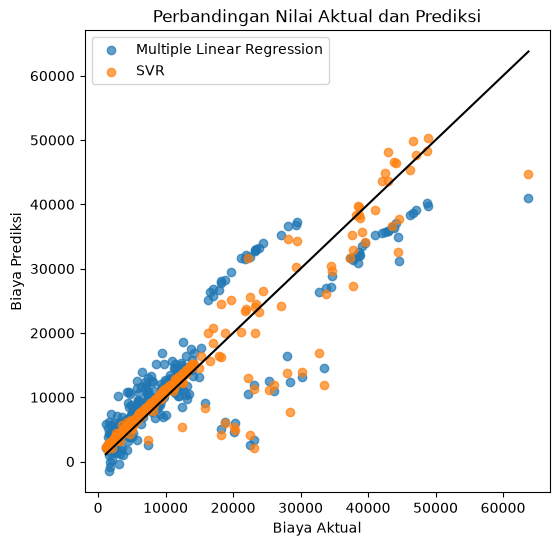

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_linear, alpha=0.7, label='Multiple Linear Regression')
plt.scatter(y_test, y_pred_svr, alpha=0.7, label='SVR')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black')
plt.xlabel('Biaya Aktual')
plt.ylabel('Biaya Prediksi')
plt.title('Perbandingan Nilai Aktual dan Prediksi')
plt.legend()
plt.show()

## Analisis hasil

SVR memberikan hasil lebih baik pada data uji. Nilai R squared SVR lebih tinggi, sedangkan MAE dan MSE lebih rendah dibandingkan multiple linear regression.